In [18]:
import numpy as np, time


dtype = np.dtype([
    ('x1', np.float32),
    ('y1', np.float32),
    ('x2', np.float32),
    ('y2', np.float32),
    ('conf', np.float32),
    ('class_id', np.float32)
])

MAX_OBJ = 3

meta_dtype = np.dtype([
    ('count', np.int32),
    ('ts', np.float64),
    ('objects', dtype, MAX_OBJ)
])
d = np.zeros(1, dtype=meta_dtype)

In [23]:
print(d['objects'])

[[(0., 0., 0., 0., 0., 0.) (0., 0., 0., 0., 0., 0.)
  (0., 0., 0., 0., 0., 0.)]]


In [ ]:
import random
step = [0.97, 1.08]
for i in range(100):
    print(step[i % 2] * random.uniform(0.8, 1.2))

0.8431897408231105
1.1628945513213305
1.049866295256469
1.0255017935491892
1.0054886494353463
1.004648153722311
1.0496440506142068
1.0765937712130929
0.8763180906253992
0.9200142163283705
0.8172069847317736
0.9483516174811847
0.9328926628108551
1.0577879556001102
1.0414256853192703
1.256835185498986
1.022866812447393
1.2904074830534729
0.7777358767622153
0.9854787220872259
1.0103986786417516
0.8675136880600237
0.9073519569963816
1.092338850300273
1.1454538768393623
1.088274811608366
0.936734282179999
1.0044160860031577
1.0847082374133195
1.2095392023901559
0.8593936709315411
1.1303630748018134
0.9886465995066043
1.004518113934326
0.9156544212287492
1.2536188637812171
1.0000434585019975
1.1054559794680099
0.8249913650414799
0.9572721462970529
0.8641818727655739
0.88014498004507
1.0644968102485555
1.0434049698226078
1.0284805492955327
0.9605908210000479
0.8635151392036372
1.0646573840020404
1.0430151118135946
1.0111211513940126
0.9477032715225128
1.0353460795505633
1.1117508786468788
0.8

In [53]:
import random
cam_range = (0.1, 10.0)

random.uniform(*cam_range)

6.152123053071851

In [ ]:
# to make perpendicular point from a vector
import numpy as np

pole1 = (-80, 20)
pole2 = (-230, 20)

x1, y1 = pole1
x2, y2 = pole2

v1 = np.array([x2 - x1, y2 - y1])

print(v1)

v1_perp = np.array([-v1[1], v1[0]])

v1_perp = v1_perp / np.sqrt(v1_perp[0]**2 + v1_perp[1]**2)
print(v1_perp)

c = 1
offset = np.array(pole2) + c * v1_perp
print(offset)

[-150    0]
[ 0. -1.]
[-230.   19.]


In [ ]:
#better way to do this

def perpendicular_offset(point_a, point_b, origin_point, clearance):
    """
    Compute point = point_b offset by `clearance` meters perpendicular to line (point_a->point_b).
    `origin_point` is used to choose which side of the line we want:
      - if the normal points toward origin_point, keep it; otherwise flip it.
    Returns numpy array [x, y].
    """
    a = np.asarray(point_a, dtype=float)
    b = np.asarray(point_b, dtype=float)
    origin = np.asarray(origin_point, dtype=float)

    # direction from a -> b
    v = b - a
    if np.allclose(v, 0):
        raise ValueError("pole points are identical")

    # 90° rotation (one perpendicular)
    n = np.array([-v[1], v[0]], dtype=float)

    # normalize to unit length
    n /= np.linalg.norm(n)

    # choose side: make the normal point toward `origin` (or away by flipping sign)
    to_origin = origin - ((a + b) / 2.0)   # vector from center-of-poles to origin
    if np.dot(n, to_origin) < 0:
        n = -n

    # final offset point (from pole b)
    return b + clearance * n

Number of passes needed with 30% overlap: 11
[-150   70]
154.9831065219


Text(0.5, 1.0, 'Capsule Boundary Points')

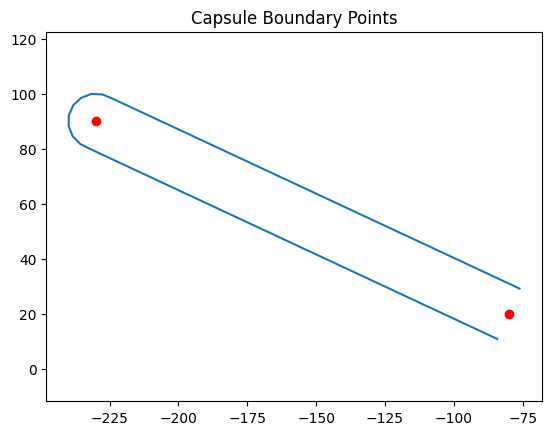

In [ ]:
import numpy as np


def capsule_boundary_point(A, B, r, tau):
    """
    tau ∈ [0,1] = global progress around capsule
    returns a point on the capsule boundary
    """

    A = np.array(A, dtype=float)
    B = np.array(B, dtype=float)

    v = B - A
    L = np.linalg.norm(v)

    u = v / L
    n = np.array([-u[1], u[0]])

    P = 2*L + 2*np.pi*r   # total perimeter
    t = tau * P           # convert normalized → arc length
    # print(f"tau = {tau},t = {t}")


    # ----- Region 1 : Top line -----
    
    if t < L:
        s = t / L
        p =  A + r*n + s*v
        segment = 0

    # ----- Region 2 : Semicircle at B -----
    elif t < L + np.pi*r:
        t2 = t - L
        theta = t2/r - np.pi/2
        p = B + r*(np.cos(theta)*u - np.sin(theta)*n)
        segment = 1

    # ----- Region 3 : Bottom line -----
    elif t < 2*L + np.pi*r:
        t3 = t - (L + np.pi*r)
        s = t3 / L
        p =  B - r*n - s*v
        segment = 2

    # ----- Region 4 : Semicircle at A -----
    else:
        t4 = t - (2*L + np.pi*r)
        theta = t4/r - np.pi/2
        p=  A + r*(-np.cos(theta)*u + np.sin(theta)*n)
        segment = 3
    return np.array([p[0], p[1], segment])

import matplotlib.pyplot as plt

A = (-80, 20)
B = (-230, 90)
r = 10
N = 100
points = [capsule_boundary_point(A, B, r, i/(N-1)) for i in range(N)]

v = np.array(B) - np.array(A)
L = np.linalg.norm(v)
P = 2*L  + 2*np.pi*r



print(v)
angle = np.arctan2(v[1], v[0])
print(np.rad2deg(angle))


points = np.array(points)
mask = points[:,2] != 3
plt.plot(points[mask,0], points[mask,1], label='Capsule Boundary')
plt.scatter([A[0], B[0]], [A[1], B[1]], color='red', label='Poles')
plt.axis('equal')
plt.title('Capsule Boundary Points')

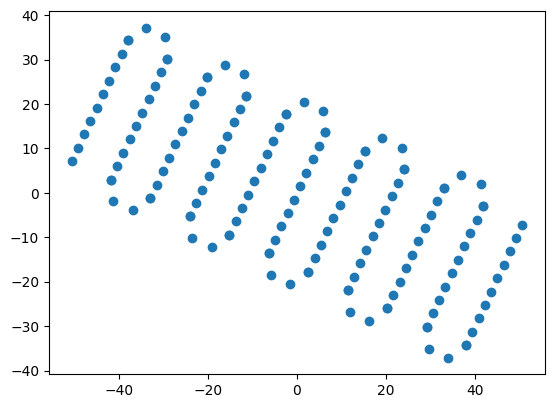

In [74]:
#create the scanning pattern


import numpy as np
import matplotlib.pyplot as plt


def generate_scan(area_width, area_length, altitude, fov_deg, overlap,
                  N_line=10, N_turn=4):

    # --- camera footprint ---
    swath = 2 * altitude * np.tan(np.radians(fov_deg/2))
    lane_spacing = swath * (1 - overlap)

    # --- number of lanes ---
    n_lanes = int(np.ceil(area_width / lane_spacing))

    # --- center lanes ---
    total_span = (n_lanes - 1) * lane_spacing
    x0 = -total_span / 2
    lane_x = x0 + np.arange(n_lanes) * lane_spacing

    # --- turn radius ---
    r = lane_spacing / 2

    half_len = area_length / 2

    waypoints = []

    for i in range(n_lanes):

        x = lane_x[i]

        # alternate direction
        going_up = (i % 2 == 0)

        if going_up:
            y_start, y_end = -half_len, half_len
        else:
            y_start, y_end = half_len, -half_len

        # --- straight lane ---
        ys = np.linspace(y_start, y_end, N_line)
        xs = np.full_like(ys, x)
        waypoints.extend(zip(xs, ys))

        # --- turn ---
        if i < n_lanes - 1:

            x_next = lane_x[i+1]
            y_turn = y_end

            cx = (x + x_next) / 2
            cy = y_turn

            if going_up:
                theta = np.linspace(np.pi, 0, N_turn)
            else:
                theta = np.linspace(0, np.pi, N_turn)

            arc_x = cx + r*np.cos(theta)
            if going_up:
                arc_y = cy + r*np.sin(theta)
            else:
                arc_y = cy - r*np.sin(theta)

            waypoints.extend(zip(arc_x, arc_y))

    return np.array(waypoints)

if __name__ == "__main__":
    area_width, area_length = 100.0, 30.0   # meters (width across lanes, length along flight)
    alt = 10.0
    fov = 70.0
    overlap = 0.30
    pts = generate_scan(area_width, area_length, alt, fov, overlap, N_line=10, N_turn=4)
    pts = np.array(pts) + np.array([0, 0])  # shift down to center in plot
    vx = -150
    vy = 70
    v = np.array([vx, vy])
    theta = np.arctan2(v[1], v[0])
    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    pts  = (pts @ R.T)

    import matplotlib.pyplot as plt

    plt.scatter(pts[:,0], pts[:,1])
    plt.gca().set_aspect('equal')
    plt.show()

In [36]:
import numpy as np
import matplotlib as pyplot

ab = np.array([3,-5])
ap = np.array([3,-2])
print(f"ab {ab}, ap {ap}")

print(f"dot {np.dot(ab, ap)}")
print(f"cross {np.cross(ab, ap)}")

ab [ 3 -5], ap [ 3 -2]
dot 19
cross 9


/tmp/ipykernel_72423/3884354102.py:9: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  print(f"cross {np.cross(ab, ap)}")


In [7]:
pole1 = (-80, 20)
pole2 = (-230, 20)

a = (-80, 100)
b = (220, 65)

ab = np.array(b) - np.array(a)

print(ab)

import numpy as np

p = np.array([pole1, pole2])

for i in p:
    ap = np.array(i) - np.array(a)
    c = np.cross(ab, ap)
    dot = np.dot(ab, ap)
    dist = np.abs(c)/ np.linalg.norm(ab)
    t = (np.dot(ab, ap)) / np.dot(ab, ab)
    print(f"pole {i}, cross {c}, dot {dot}, dist {dist}, t {t}")

[300 -35]
pole [-80  20], cross -24000, dot 2800, dist 79.46105112697943, t 0.03069334064127158
pole [-230   20], cross -29250, dot -42200, dist 96.84315606100618, t -0.46259249109345024


/tmp/ipykernel_82469/343980445.py:17: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  c = np.cross(ab, ap)
